# GLP-1R：RDKit → PyTorch EC50 预测 → 描述符梯度

这个 Demo 完成以下流程：

1. 输入一个 SMILES，并显示结构与 RDKit 分子性质；
2. 加载已经训练好的单隐藏层 PyTorch 模型；
3. 预测 Assay 1 的 pEC50 和 EC50 (nM)；
4. 反向传播得到每个 RDKit 描述符的局部导数；
5. 在连续标准化描述符空间演示梯度上升；
6. 对你提供的真实候选 SMILES 进行预测排序。

> **重要限制**：SMILES、原子类型和 RDKit 描述符计算是离散且不可微的，因此不能直接计算“对 SMILES 字符的导数”。这里计算的是 `∂pEC50/∂RDKit descriptor`。连续空间优化结果是设计方向，不是自动生成的合法分子。当前模型骨架交叉验证 R² 仍为负，只适合方法演示与候选排序，不适合直接做实验决策。

In [2]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, Draw
from IPython.display import display

torch.set_num_threads(1)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = Path.cwd()
candidate_dirs = [
    PROJECT_DIR / "model_output_torch_pca_fin",  # 用户选定的最终 PCA 模型
    PROJECT_DIR / "model_output_torch_pca",  # PCA 已嵌入模型第一层
]
MODEL_DIR = next((p for p in candidate_dirs if (p / "glp1r_assay1_torch_model.pt").exists()), None)
if MODEL_DIR is None:
    raise FileNotFoundError(
        "没有找到 model_output_torch_pca_fin 或 model_output_torch_pca；"
        "请先运行新版 train_glp1r_pytorch.py"
    )

MODEL_PATH = MODEL_DIR / "glp1r_assay1_torch_model.pt"
print("使用模型：", MODEL_PATH)


使用模型： /Users/wiswolf/Desktop/PDkitmap script/model_output_torch_pca_fin/glp1r_assay1_torch_model.pt


## 1. 加载网络（PCA 是冻结的第一层）

In [4]:
class PCAFirstLayerNet(nn.Module):
    def __init__(self, input_dim: int, pca_dim: int, hidden_dim: int = 16):
        super().__init__()
        self.register_buffer("impute_values", torch.zeros(input_dim))
        self.network = nn.Sequential(
            nn.Linear(input_dim, pca_dim),
            nn.Linear(pca_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.network[0].weight.requires_grad_(False)
        self.network[0].bias.requires_grad_(False)

    def forward(self, x):
        x = torch.where(torch.isfinite(x), x, self.impute_values)
        return self.network(x).squeeze(-1)


checkpoint = torch.load(MODEL_PATH, map_location="cpu")
if checkpoint.get("activation") != "SiLU":
    raise RuntimeError(
        "当前 checkpoint 不是 SiLU 模型；请用新版 train_glp1r_pytorch.py 重新训练"
    )

model = PCAFirstLayerNet(
    checkpoint["input_dim"], checkpoint["pca_dim"], checkpoint["hidden_dim"]
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_mean = float(checkpoint["y_mean"])
y_std = float(checkpoint["y_std"])
descriptor_names = list(checkpoint["descriptor_names"])
descriptor_scale = np.asarray(checkpoint["descriptor_scale"], dtype=np.float32)

# 必须和训练脚本保持相同的描述符顺序。
descriptor_functions = [(name, fn) for name, fn in Descriptors._descList if name != "Ipc"]
assert [name for name, _ in descriptor_functions] == descriptor_names

print(model)
print(
    f"原始 RDKit 输入：{checkpoint['input_dim']} 维；"
    f"冻结 PCA 输出：{checkpoint['pca_dim']} 维；隐藏层：{checkpoint['hidden_dim']} 维"
)
assert checkpoint["input_dim"] == len(descriptor_names)
assert checkpoint["pca_first_layer_frozen"] is True
assert model.network[0].weight.requires_grad is False


PCAFirstLayerNet(
  (network): Sequential(
    (0): Linear(in_features=216, out_features=25, bias=True)
    (1): Linear(in_features=25, out_features=16, bias=True)
    (2): SiLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)
原始 RDKit 输入：216 维；冻结 PCA 输出：25 维；隐藏层：16 维


## 2. 输入一个分子并查看 RDKit 输出

只需要修改下面的 `SMILES`。

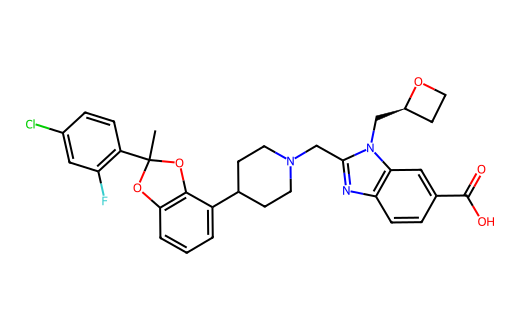

,RDKit output
Canonical SMILES,CC1(c2ccc(Cl)cc2F)Oc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)cc5n4C[C@@H]4CCO4)CC3)c2O1
Molecular formula,C32H31ClFN3O5
Molecular weight,592.067
cLogP,6.3396
TPSA (Å²),86.05
H-bond donors,1
H-bond acceptors,6
Rotatable bonds,7
Ring count,7
Formal charge,0


In [6]:
SMILES = "CC1(c2ccc(Cl)cc2F)Oc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)cc5n4C[C@@H]4CCO4)CC3)c2O1"

mol = Chem.MolFromSmiles(SMILES)
if mol is None:
    raise ValueError("无效 SMILES，请检查括号、环编号和手性标记")

canonical_smiles = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
display(Draw.MolToImage(mol, size=(520, 330)))

basic_properties = pd.Series({
    "Canonical SMILES": canonical_smiles,
    "Molecular formula": rdMolDescriptors.CalcMolFormula(mol),
    "Molecular weight": Descriptors.MolWt(mol),
    "cLogP": Crippen.MolLogP(mol),
    "TPSA (Å²)": rdMolDescriptors.CalcTPSA(mol),
    "H-bond donors": Lipinski.NumHDonors(mol),
    "H-bond acceptors": Lipinski.NumHAcceptors(mol),
    "Rotatable bonds": Lipinski.NumRotatableBonds(mol),
    "Ring count": Lipinski.RingCount(mol),
    "Formal charge": Chem.GetFormalCharge(mol),
})
display(basic_properties.to_frame("RDKit output"))


## 3. 计算完整 RDKit 描述符并预测 EC50

In [17]:
def calculate_descriptor_vector(molecule):
    values = []
    for name, fn in descriptor_functions:
        try:
            value = float(fn(molecule))
            values.append(value if math.isfinite(value) else np.nan)
        except Exception:
            values.append(np.nan)
    return np.asarray(values, dtype=float)


def predict_rdkit_vector(rdkit_vector):
    '''输入一个 216 维原始 RDKit 描述符向量，输出 (pEC50, EC50_nM)。'''
    values = np.asarray(rdkit_vector, dtype=np.float32).reshape(-1)
    if values.shape != (checkpoint["input_dim"],):
        raise ValueError(
            f"需要 {checkpoint['input_dim']} 维 RDKit 描述符，实际得到 {values.size} 维"
        )
    model_input = torch.from_numpy(values.reshape(1, -1))
    with torch.no_grad():
        prediction_z = model(model_input).item()
    pec50 = prediction_z * y_std + y_mean
    ec50_nm = 10 ** (9.0 - pec50)
    return float(pec50), float(ec50_nm)


# 运行流程明确拆开：SMILES -> RDKit Mol -> 216维描述符 -> 模型预测。
mol_for_prediction = Chem.MolFromSmiles(SMILES)
if mol_for_prediction is None:
    raise ValueError("无效 SMILES")
raw_descriptors = calculate_descriptor_vector(mol_for_prediction)


pEC50_pred, EC50_nM_pred = predict_rdkit_vector(raw_descriptors)
model_features = raw_descriptors.reshape(1, -1).astype(np.float32)


print(f'raw_descriptors是RDkit的输出维度是: {raw_descriptors.shape}')
print(f"Predicted pEC50 : {pEC50_pred:.3f}")
print(f"Predicted EC50  : {EC50_nM_pred:.3f} ")

descriptor_table = pd.DataFrame({
    "descriptor": descriptor_names,
    "value": raw_descriptors.ravel(),
}).sort_values("descriptor")
display(descriptor_table.head(30))


raw_descriptors是RDkit的输出维度是: (216,)
Predicted pEC50 : 7.964
Predicted EC50  : 10.860 


,descriptor,value
26,AvgIpc,3.467642
20,BCUT2D_CHGHI,2.425940
21,BCUT2D_CHGLO,-2.328510
22,BCUT2D_LOGPHI,2.494942
23,BCUT2D_LOGPLOW,-2.352296
24,BCUT2D_MRHI,6.301208
25,BCUT2D_MRLOW,-0.071157
18,BCUT2D_MWHI,35.495693
19,BCUT2D_MWLOW,9.883363
27,BalabanJ,1.078765


## 4. 反向传播：预测值对 RDKit 描述符的导数

网络直接接收全部原始 RDKit 描述符，内部冻结的第一层完成缺失值填补、标准化和 PCA 投影。PyTorch 会把梯度穿过 PCA 层反传到全部原始描述符。

- `gradient_standardized`：描述符增加 1 个训练集标准差时，pEC50 的局部变化，适合比较重要性；
- `dpEC50_dDescriptor`：对原始描述符单位的导数；
- `dEC50nM_dDescriptor`：对 EC50 (nM) 的导数；
- 正梯度：增加该描述符，模型局部预测 pEC50 增加、EC50 降低；负梯度相反。

In [24]:
features_tensor = torch.tensor(model_features, dtype=torch.float32, requires_grad=True)
predicted_z = model(features_tensor)
predicted_pec50_tensor = predicted_z * y_std + y_mean  #提前有标准化 这里是逆过程
predicted_pec50_tensor.backward()

gradient_raw = features_tensor.grad.detach().numpy().ravel()



In [26]:
# 原始单位导数乘训练集标准差，表示“该描述符改变 1 SD”的局部影响。
gradient_standardized = gradient_raw * descriptor_scale

# EC50 = 10^(9-pEC50)
gradient_ec50_raw = -np.log(10.0) * EC50_nM_pred * gradient_raw

gradient_table = pd.DataFrame({
    "descriptor": descriptor_names,
    "descriptor_value": raw_descriptors.ravel(),
    "gradient_standardized": gradient_standardized,
    "dpEC50_dDescriptor": gradient_raw,
    "dEC50nM_dDescriptor": gradient_ec50_raw,
})
gradient_table["abs_standardized_gradient"] = gradient_table["gradient_standardized"].abs()
gradient_table["model_direction"] = np.where(
    gradient_table["gradient_standardized"] > 0,
    "increase → predicted potency up",
    "increase → predicted potency down",
)
gradient_table = gradient_table.sort_values("abs_standardized_gradient", ascending=False)
display(gradient_table.head(20))


,descriptor,descriptor_value,gradient_standardized,dpEC50_dDescriptor,dEC50nM_dDescriptor,abs_standardized_gradient,model_direction
93,EState_VSA9,30.795507,0.058529,0.013518,-0.338039,0.058529,increase → predicted potency up
16,FpDensityMorgan2,1.928571,0.056987,1.339984,-33.508415,0.056987,increase → predicted potency up
15,FpDensityMorgan1,1.119048,0.055647,1.566061,-39.161819,0.055647,increase → predicted potency up
17,FpDensityMorgan3,2.642857,0.052679,1.079452,-26.993408,0.052679,increase → predicted potency up
95,VSA_EState10,5.968031,0.041965,0.014950,-0.373851,0.041965,increase → predicted potency up
178,fr_imidazole,1.000000,-0.040494,-0.151068,3.777684,0.040494,increase → predicted potency down
73,SlogP_VSA12,11.600940,0.040061,0.007375,-0.184415,0.040061,increase → predicted potency up
79,SlogP_VSA7,5.022633,0.040061,0.017034,-0.425950,0.040061,increase → predicted potency up
18,BCUT2D_MWHI,35.495693,0.037927,0.004494,-0.112379,0.037927,increase → predicted potency up
96,VSA_EState2,18.909878,-0.035803,-0.008848,0.221254,0.035803,increase → predicted potency down


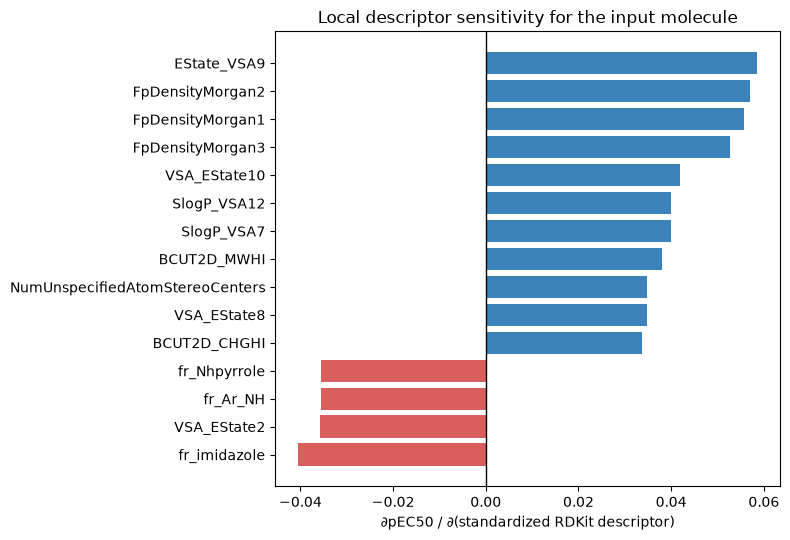

In [11]:
top = gradient_table.head(15).sort_values("gradient_standardized")
colors = ["#d95f5f" if x < 0 else "#3a82b7" for x in top["gradient_standardized"]]
plt.figure(figsize=(8, 5.5))
plt.barh(top["descriptor"], top["gradient_standardized"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("∂pEC50 / ∂(standardized RDKit descriptor)")
plt.title("Local descriptor sensitivity for the input molecule")
plt.tight_layout()
plt.show()


In [15]:
print(predicted_z)

tensor([0.3058], grad_fn=<SqueezeBackward1>)
